In [163]:
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy.stats as stats
import random

Zadanie 1:
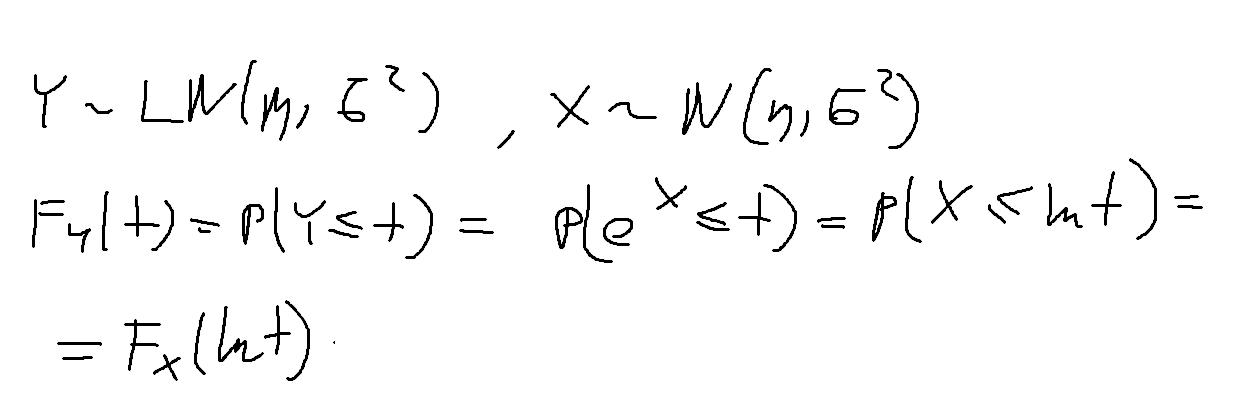

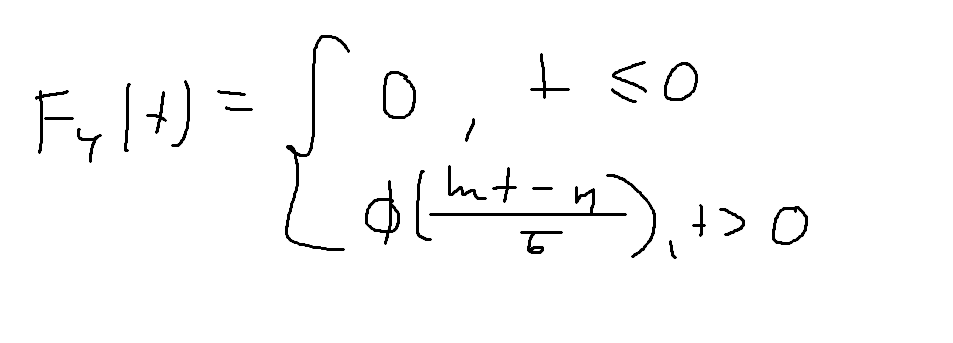

b) Wyznacz gęstość zmiennej losowej Y


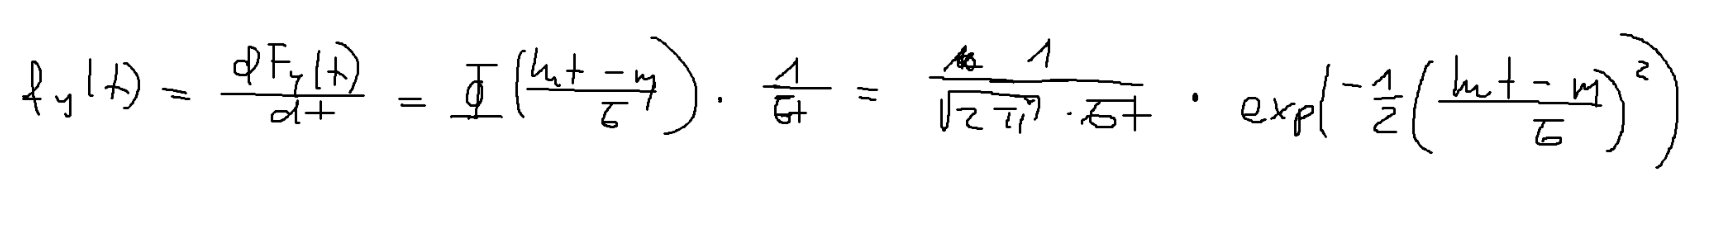

c) Wyznacz wartość oczekiwaną oraz wariancję zmiennej losowej Y

d) Zaproponuj metodę symulacji zmiennej losowej Y
-> Metoda odwróconej dystrybuanty odpada, bo wymagałoby to rozw równania: Y = F_Y(U)^-1, które nie ma prostej postaci analitycznej.
Inna metoda, skoro Y = e^X, to symulujemy X, korzystamy z tego wzoru i możemy generować zmienną Y

In [164]:
def generate_normal(mean, sigma, size = 1000):
    X = np.random.normal(loc=mean, scale=math.sqrt(sigma), size=size) 
    # size definiuje ile próbek otrzymamy (1000 - tysiąc wartości), zapis w krotce oznacza (x1,x2,..., xn)
    # definiuje, ile wymiarową tablicę otrzymamy (łączna ilość wartości to x1*x2...xn)
    return X

def log_normal(X):
    Y = np.e**X
    return Y

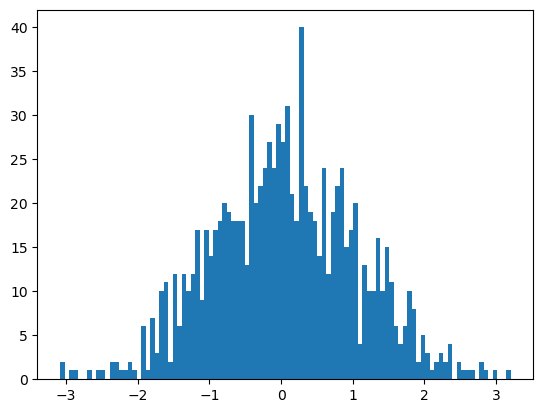

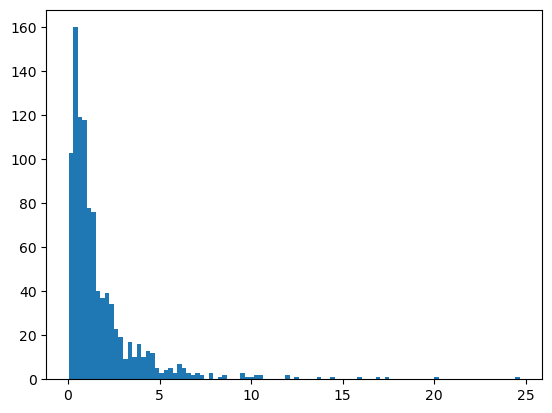

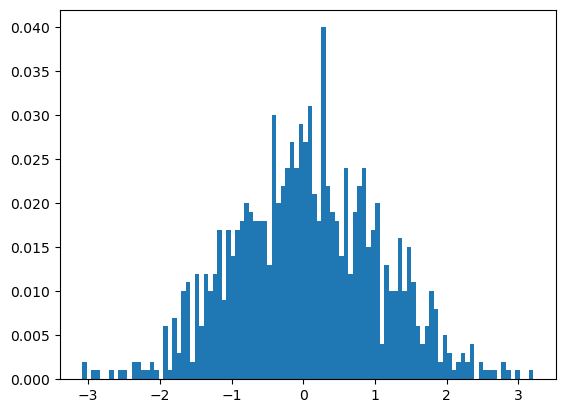

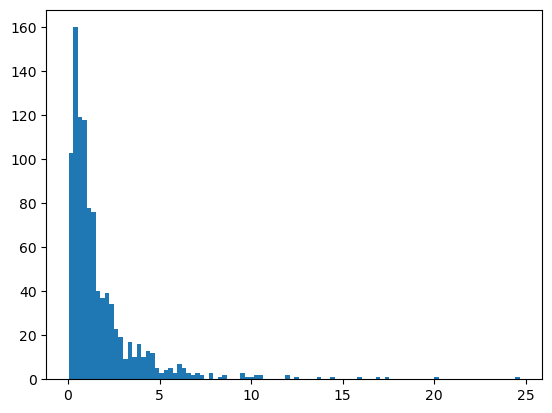

In [165]:
size = 1000
median = 0
variance = 1
sigma = np.sqrt(variance)

X = generate_normal(median, variance, size)
Y = log_normal(X)

# histogramy liczności
# parametr bins oznacza, ile mamy przedziałów na osi X
plt.hist(X, bins=100)
plt.show()
plt.hist(Y, bins=100)
plt.show()

#histogramy częstości
plt.hist(X, bins=100,weights=np.ones(len(X))/len(X)) # np.ones(n) tworzy [1,1,1, ..., 1] (lista n jedynek)
plt.show()
plt.hist(Y, bins=100)
plt.show()

g) Narysuj histogramy unormowane (gęstościowe) dla X oraz Y tak, aby mogły być porównane z
gęstościami teoretycznymi. Na wykresach nanieś również teoretyczne gęstości.

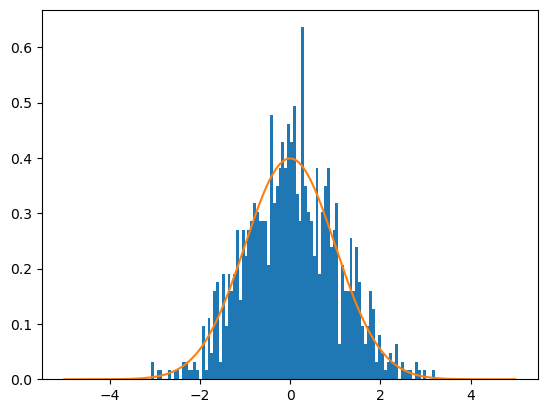

In [166]:
plt.hist(X, bins = 100, density=True)
xpdf = np.arange(-5,5,0.01) # np.arange: zakres <x_p, x_k>, trzeci parametr oznacza krok
# podobne do np.linspace(x_p, x_k, n), gdzie n oznacza liczbę kroków

pdf = 1 / (np.sqrt(2*np.pi)*sigma) * np.exp(-(xpdf-median)**2/(2*sigma**2))
# alternatywnie 
pdf_2 = stats.norm.pdf(xpdf)


plt.plot(xpdf, pdf_2)
plt.show()

h) Wyznacz gęstości empiryczne przy pomocy estymatora jądrowego i porównaj je z gęstościami
teoretycznymi.

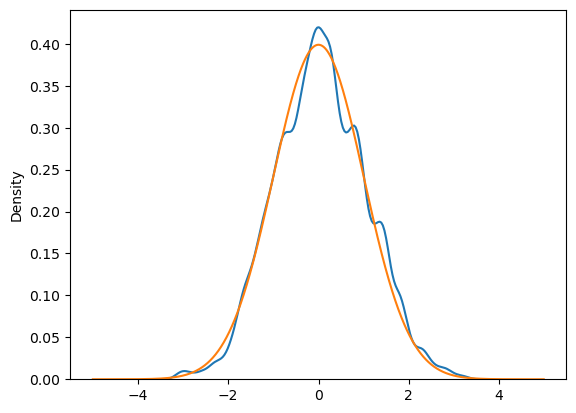

In [167]:
import seaborn as sns

sns.kdeplot(X, bw_adjust=0.5)
plt.plot(xpdf, pdf)


i) Oblicz skośność oraz kurtozę dla X oraz Y i skomentuj różnice.

In [168]:
skewness_x = stats.skew(X) # bias stosuje estymator nieobciążony, co poprawia ostateczne wyniki dla małych wartości n(dla False poprawia)
skewness_y = stats.skew(Y)
print(skewness_x)
print(skewness_y)
# mój komentarz: skośność dla x wynosi prawie zero, co oznacza że dane są prawie symetrycznie dystrybuowane
# skośność dla y: po stronie prawej występuje więcej 'niestandardowo' dużych wartości (długi ogon po prawej stronie)

kurt_x = stats.kurtosis(X, fisher=False)
kurt_y = stats.kurtosis(Y, fisher=False)
print(kurt_x)
print(kurt_y)
# rozkład normalny - mała kurtoza, większość wartości jest przy wartości oczekiwanej, mało wartości 'ekstremalnych'
# rozkład log_normalny - duża kurtoza, dużo wartości daleko od wartości oczekiwanej


0.04234324594917453
3.985408219264158
2.9193887258378837
27.090705661381538


Zadanie 2:
a) wyznacz gęstość - pochodna dystrybuanty
b) wartość oczekiwana/wariancja - całka
c) Wysymuluj próbę losową dla n = 1000 dla wybranego zestawu parametrów gdzie alfa > 2

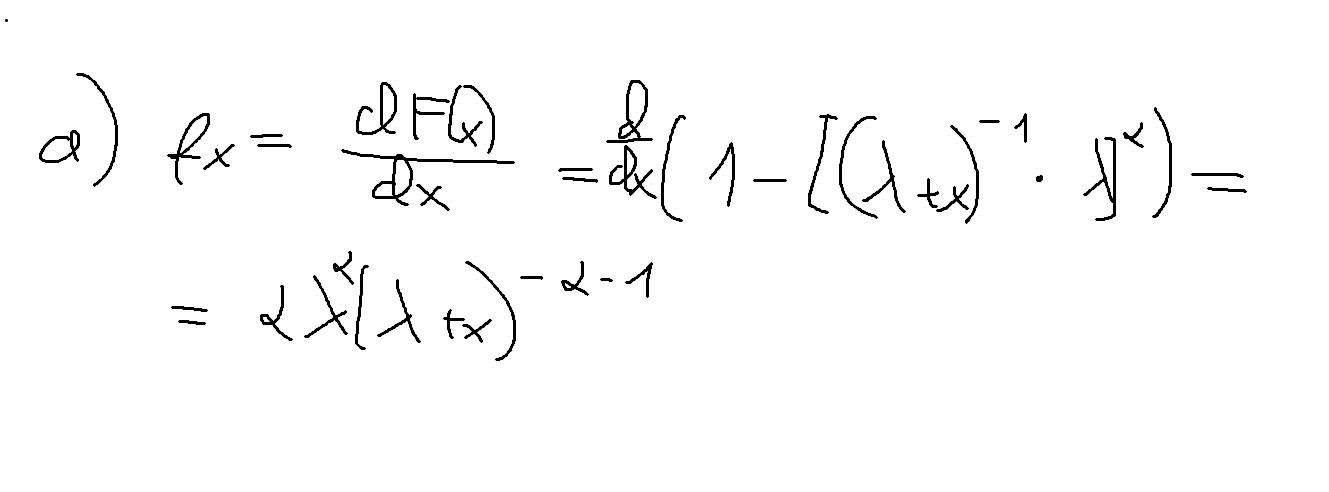

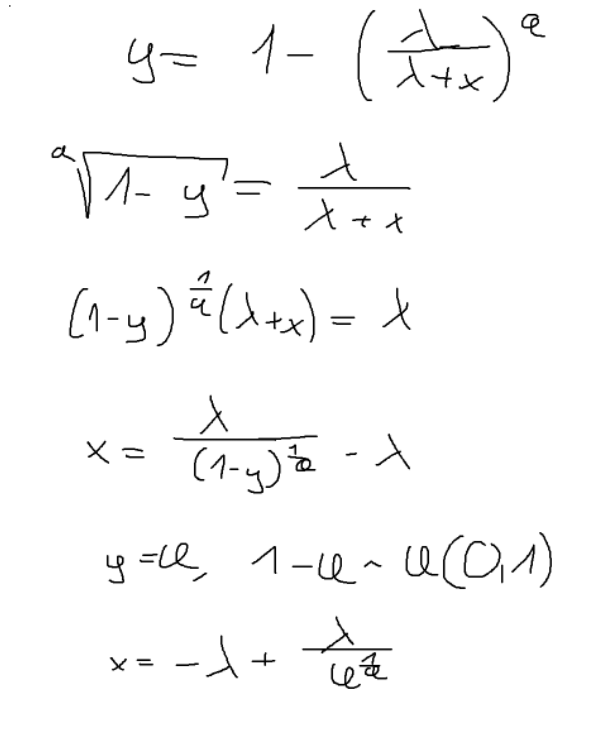

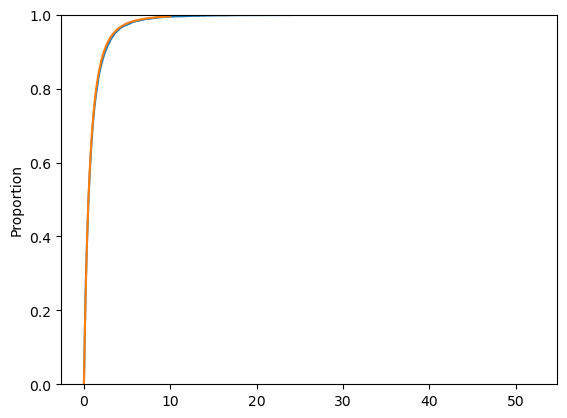

In [169]:
n = 10000
alfa = 3
lam = 2
x_distr = np.arange(0, 10, 0.01)
X = []

for _ in range(n):
    U = random.random()
    X.append(- lam + lam / (U**(1 / alfa)))

sns.ecdfplot(X) # dystrybuanta empiryczna
theory_distribution = 1 - (lam / (lam + x_distr))**alfa
plt.plot(x_distr, theory_distribution)
plt.show()


e) Porównaj gęstość empiryczną z gęstością teoretyczną

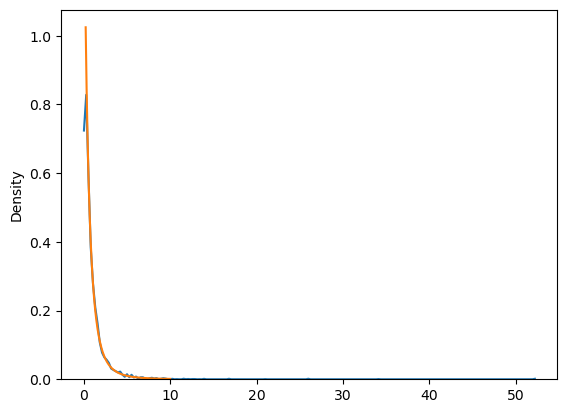

In [170]:
x_pdf = np.arange(0.2, 10, 0.01)
pdf = alfa*lam**alfa*(lam + x_pdf) ** (-alfa - 1)

#plt.hist(X, bins = 100, density=True) # gęstośc empiryczna
sns.kdeplot(X, bw_adjust=0.1, cut=0)
plt.plot(x_pdf, pdf) # gęstość teoretyczna
plt.show()

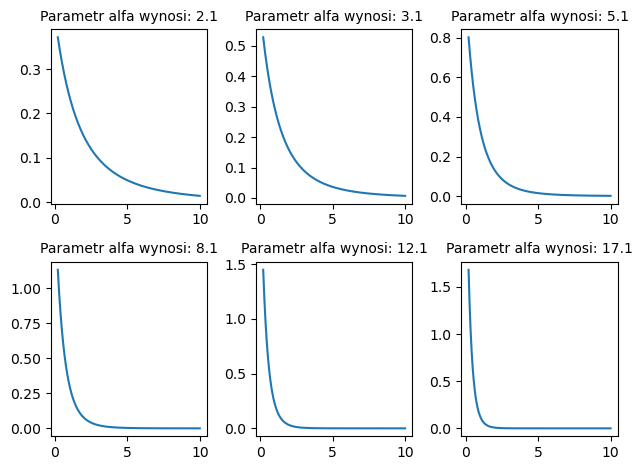

[np.float64(1.7063558244659527), np.float64(3.1502366963370125), np.float64(6.444310310603521), np.float64(11.815819316536889), np.float64(19.211717840020537), np.float64(28.555580380214373)]


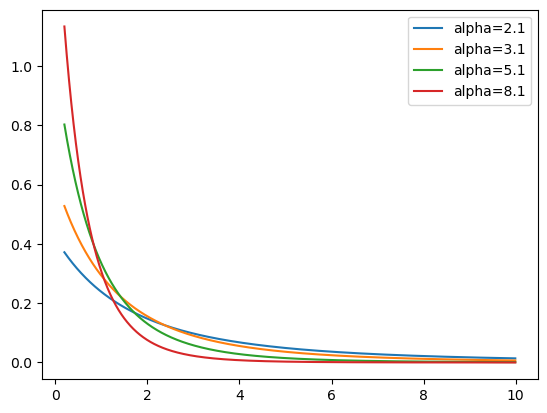

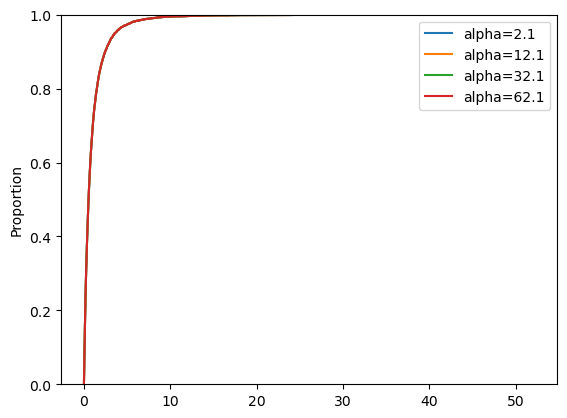

[np.float64(1.7063558244659527), np.float64(3.1502366963370125), np.float64(6.444310310603521), np.float64(11.815819316536889), np.float64(19.211717840020537), np.float64(28.555580380214373)]


In [ ]:
lam = 5
alfa = 2.1
kurtosis_t = []
for i in range(6):
    alfa += i
    pdf = alfa*lam**alfa*(lam + x_pdf) ** (-alfa - 1)
    plt.subplot(2,3,i+1)
    plt.plot(x_pdf, pdf)
    plt.title(f'Parametr alfa wynosi: {alfa}',fontsize = 10)
    kurtosis_t.append(stats.kurtosis(pdf))
plt.tight_layout()
plt.show()

print(kurtosis_t)


lam = 5
alfa = 2.1
for i in range(4):
    alfa += i
    pdf = alfa*lam**alfa*(lam + x_pdf) ** (-alfa - 1)
    plt.plot(x_pdf, pdf, label=f'alpha={alfa}')
plt.legend()
plt.show()


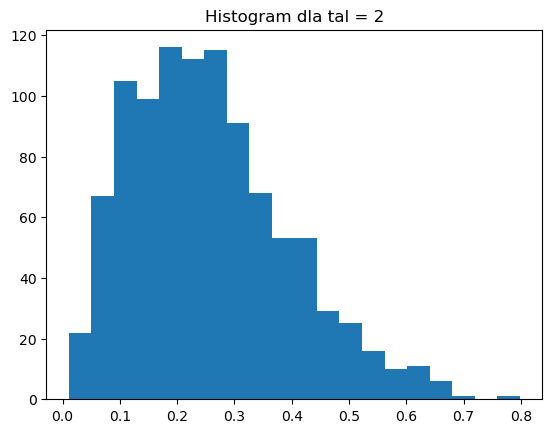

In [ ]:
X_burr = []
tal = 2
for i in range(1000):
    U = random.random()
    x_ = - lam + lam / (U**(1 / alfa))
    X_burr.append(x_**(1/tal))

plt.hist(X_burr, bins=20)
plt.title(f'Histogram dla tal = {tal}')
plt.show()

plt.plot(x_pdf, pdf)
sns.kdeplot(X_burr, bw_adjust=0.1, cut=0)
plt.hist()